# Finding rare (un-annotated) cell types with DRVI

Rare cell types / states are often *missing from the annotations* of a dataset: there are too few of them to
form their own cluster, so they get absorbed into a neighboring cell type's label. DRVI, however, tends
to give such a population its **own latent dimension**, because the population has a distinct gene program.

In this notebook we define a rare-cell-type dimension by **three criteria** and use them to scan the
DRVI latent space of the immune dataset:

1. **Rare activity** — Only a small fraction of cells are *active* on the dimension.
2. **Spatial cohesion** — The active cells sit close together in the latent manifold, rather than being scattered.
3. **Interpretability** — The dimension has a significant gene program signature.

The immune dataset (human PBMC / bone marrow) has **no `Fibroblast` annotation**. Yet a handful of
fibroblast contaminant cells are present. We will *discover* them as a dimension that meets the three
criteria, use the interpretability scores to *hypothesize* their identity, and finally prove it with
the canonical fibroblast marker **`COL1A1`** — a gene that was not among the 2000 highly variable
genes (HVGs) the model was trained on, but is present in the full data.

We reuse the **already-trained** model from the general DRVI pipeline — there is no retraining here.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, the next cell will install dependencies.

Please remove this part if your environment is already setup.

In [1]:
import sys

# if branch is stable, will install via pypi, else will install from source
branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    !pip install drvi-py[tutorials]
    pass
elif IN_COLAB and branch != "stable":
    !pip install git+https://github.com/theislab/drvi.git#egg=drvi-py[tutorials]
    pass

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc

from scipy.spatial.distance import pdist

import scvi
import drvi
from drvi.model import DRVI

In [4]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.3
Last run with DRVI version: 0.2.6


In [5]:
# Making plots prettier
sc.set_figure_params(dpi=100, frameon=False, figsize=(3, 3))

from matplotlib import pyplot as plt
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (3, 3)

## Config

We load the artifacts produced by the general training/interpretability pipeline:

- `drvi_model` — the trained DRVI model.
- `embed.h5ad` — the latent space (one column per latent dimension) with dimension stats in `embed.var`
  and pre-computed interpretability scores in `embed.varm`.
- `adata_preprocesses.h5ad` — the pre-processed counts (2000 HVGs) the model was trained on.
- `immune_all.h5ad` — the *full* gene set (used only at the end to validate with the held-out marker).

In [6]:
io_dir = Path("./tmp_io/drvi_immune_128/")

embed_path = io_dir / "embed.h5ad"
adata_path = io_dir / "adata_preprocesses.h5ad"
model_path = io_dir / "drvi_model"
full_anndata_path = io_dir.parent / "immune_all.h5ad"

# Column in `embed.obs` / full data holding the existing cell-type annotation.
CELL_TYPE_COL = "final_annotation"

# Thresholds defining a rare-cell-type dimension (see the three criteria above).
ACTIVITY_FRACTION = 0.5    # a cell is "active" if |latent| exceeds this fraction of the dimension's peak |latent|
MAX_RARE_FRACTION = 0.01   # a dimension is "rare" if fewer than this fraction of cells are active
MIN_COHESION = 0.5         # min UMAP cohesion (1 = tight blob, ->0 = spread across the UMAP)
MIN_OOD_SCORE = 1.0        # minimum interpretability score for a gene program
HOST_COVERAGE_CUTOFF = 0.30  # a candidate "needs refinement" if it captures less than this share of its host label

## Load artifacts

In [7]:
embed = sc.read_h5ad(embed_path)
adata = sc.read_h5ad(adata_path)
embed

AnnData object with n_obs × n_vars = 32484 × 128
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'qz_var'
    varm: 'IND_exp_weighted_mean_negative', 'IND_exp_weighted_mean_positive', 'IND_linear_weighted_mean_negative', 'IND_linear_weighted_mean_positive', 'IND_max_negative', 'IND_max_positive', 'OOD_combined_negative', 'OOD_combined_positive', 'OOD_max_possible_negative', 'OOD_max_possible_positive', 'OOD_min_possible_negative', 'OOD_min_possible_positive', 'PCs'
    obsp: 'connectivities', 'distances'

In [8]:
# Set up and load the trained model. We only need it for the convenience interpretability API
# (get/plot_interpretability_scores); all three criteria are computable from `embed` alone.
DRVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="batch",
    is_count_data=True,
)
model = DRVI.load(model_path, adata)
model

INFO     File tmp_io/drvi_immune_128/drvi_model/model.pt already downloaded                                        


INFO     DRVI: The model is trained with DRVI version 0.2.5.                                                       


INFO     DRVI: Updaging data setup config ...                                                                      


INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.6.                                  


INFO     DRVI: Loading model from DRVI version 0.2.5.                                                              


INFO     DRVI: Done updating model args. Loading in 0.2.6.                                                         


INFO     DRVI: The model has been initialized                                                                      


DRVI 
Latent size: 128, splits: 128, pooling of splits: 'logsumexp', 
Encoder dims: [128, 128], 
Decoder dims: [128, 128], 
Gene likelihood: pnb, 

Training status: Trained

## Scan every dimension for the three criteria

A few practical points:

- DRVI dimension **titles** do not match the column order in `embed` (e.g. `DR 1` is not the first
  column), so we always index dimensions by their title.
- We read interpretability through the model interface, `model.get_interpretability_scores(embed, adata)`.
  It returns a genes × dimensions table whose columns are the **non-vanished** signed dimensions (e.g.
  `DR 1+`).

In [9]:
# Set title as index for easier access to latent dimensions by name
embed.var.set_index("title", inplace=True, drop=False)

### Utils for criterion 1: number of active cells in a dimension

In [10]:
def active_mask(embed, dim_title_direction):
    """Boolean mask of cells active on a given dimension/direction.

    The threshold is adaptive per dimension: a cell is active when its latent value passes half of
    the dimension's peak activation (`max(|latent|) * ACTIVITY_FRACTION`) in the requested direction.
    """
    dim_title = dim_title_direction[:-1]                  # e.g. "DR 49+" -> "DR 49"
    direction = dim_title_direction[-1]                   # e.g. "DR 49+" -> "+"
    column = np.asanyarray(embed[:, dim_title].X).flatten()
    cutoff = np.abs(column).max() * ACTIVITY_FRACTION     # per-dimension: max(|latent|) / 2
    return column > cutoff if direction == "+" else column < -cutoff



### Utils for criterion 2: spatial cohesion (UMAP compactness vs Leiden clusters)

A real rare cell type forms a single tight blob rather than being scattered. We measure this directly on
the 2-D UMAP — the space we actually visualize. We cluster the latent space with **Leiden** and take the
typical *within-cluster* pairwise UMAP distance as a reference scale, then compare it to the spread of each
dimension's active cells on the UMAP:

> `cohesion = reference_cluster_scale / (reference_cluster_scale + median_pairwise_umap_distance_of_active_cells)`

This is ~1 for a tight blob and drops toward 0 as the active cells spread out.

In [11]:
sc.tl.leiden(embed, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2, directed=False)
leiden_labels = embed.obs["leiden"].to_numpy()
umap = embed.obsm["X_umap"]


def median_pairwise_distance(coords, idx, rng, max_cells=100):
    """Median pairwise distance among `idx` cells in `coords`, sub-sampled to <= max_cells for speed."""
    if len(idx) <= 1:
        return 0.0
    sample = idx if len(idx) <= max_cells else idx[rng.choice(len(idx), max_cells, replace=False)]
    return float(np.median(pdist(coords[sample])))


def umap_cohesion(active_idx, coords, cluster_scale, rng):
    """cluster_scale / (cluster_scale + median pairwise UMAP distance); 1 = tight blob, ->0 = spread."""
    return cluster_scale / (cluster_scale + median_pairwise_distance(coords, active_idx, rng))


# Reference scale: typical within-Leiden-cluster pairwise UMAP distance.
rng = np.random.RandomState(0)
UMAP_CLUSTER_SCALE = float(np.median([
    median_pairwise_distance(umap, np.where(leiden_labels == c)[0], rng)
    for c in pd.unique(leiden_labels) if (leiden_labels == c).sum() >= 10
]))
print(f"Leiden: {len(set(leiden_labels))} clusters; "
      f"typical within-cluster UMAP spread = {UMAP_CLUSTER_SCALE:.2f}.")

Leiden: 33 clusters; typical within-cluster UMAP spread = 1.43.


### Utils for criterion 3: interpretability

In [12]:
# Interpretability via the model interface: genes x non-vanished signed dimensions (e.g. "DR 49+").
interpretability_df = model.get_interpretability_scores(embed, adata)
interpretability_df.iloc[:3, :4]

title,DR 1+,DR 1-,DR 2+,DR 2-
index,,,,
TCL1A,0.0,0.009216,5.813187e-11,0.000651
IGLL5,0.0,0.001222,0.000000e+00,0.000468
PTGDS,0.0,0.001911,1.868557e-08,0.000612


### Calculating all three criteria

In [13]:
dim_stats = []
for title in embed.var["title"]:
    for direction in ["+", "-"]:
        dim_title_direction = title + direction
        
        # Find fraction of cells active on this dimension/direction (|latent| beyond the per-dimension cutoff).
        active_cells = active_mask(embed, dim_title_direction)
        n_active = active_cells.sum()
        fraction_active = n_active / embed.n_obs
        if n_active == 0:
            continue
        
        # find maximum interpretability score for this dimension/direction (i.e. strongest gene program)
        if dim_title_direction not in interpretability_df.columns:  # Vanished
            continue
        max_ood_score = interpretability_df[dim_title_direction].max().clip(1e-2, 10)  # Clipping for better visualization

        # Find UMAP cohesion of active cells (1 = tight blob, ->0 = spread across the UMAP)
        rng = np.random.RandomState(0)
        cohesion = umap_cohesion(np.where(active_cells)[0], umap, UMAP_CLUSTER_SCALE, rng)
        
        dim_stats.append(
            {
                "dim_title_direction": dim_title_direction,
                "n_active": n_active,
                "fraction_active": fraction_active,
                "max_ood_score": max_ood_score,
                "cohesion": cohesion,
            }
        )
dim_stats = pd.DataFrame(dim_stats).set_index("dim_title_direction")
dim_stats.sort_values("fraction_active")[:10]

,n_active,fraction_active,max_ood_score,cohesion
dim_title_direction,,,,
DR 6-,1,0.000031,0.010000,1.000000
DR 39-,2,0.000062,0.010000,0.070265
DR 56+,6,0.000185,5.506809,0.116949
DR 49+,11,0.000339,10.000000,0.946676
DR 53+,17,0.000523,7.863610,0.872461
DR 52-,19,0.000585,1.186559,0.877492
DR 47-,31,0.000954,9.252443,0.857012
DR 51-,39,0.001201,6.611659,0.679271
DR 50-,46,0.001416,0.362389,0.772945


## Selecting candidates

We now have all three per-dimension quantities: rarity (**fraction**, criterion 1), spatial **cohesion**
(criterion 2), and **interpretability** (criterion 3, the max OOD score). A dimension is a rare-cell-type
**candidate** when it passes all three thresholds.

In [14]:
dim_stats["is_candidate"] = (
    (dim_stats["fraction_active"] < MAX_RARE_FRACTION)
    & (dim_stats["cohesion"] > MIN_COHESION)
    & (dim_stats["max_ood_score"] > MIN_OOD_SCORE)
)
print(f"{dim_stats['is_candidate'].sum()} candidates satisfy all three criteria.")

20 candidates satisfy all three criteria.


### Ranking dimensions by a combined score

We combine the three criteria into a single score for every dimension: each is normalized to `[0, 1]` and
the three are multiplied, so a dimension must be rare **and** compact **and** interpretable to rank high.

In [15]:
def norm01(x):
    return (x - x.min()) / (x.max() - x.min())

dim_stats["rarity_score"] = norm01(-np.log10(dim_stats["fraction_active"]))   # rarer -> higher
dim_stats["cohesion_score"] = dim_stats["cohesion"]                           # already 0-1
dim_stats["interpretability_score"] = norm01(np.log10(dim_stats["max_ood_score"]))  # stronger -> higher
dim_stats["score"] = (
    dim_stats["rarity_score"] * dim_stats["cohesion_score"] * dim_stats["interpretability_score"]
)
dim_stats = dim_stats.sort_values("score", ascending=False)
dim_stats[["n_active", "fraction_active", "cohesion", "max_ood_score", "score", "is_candidate"]]

,n_active,fraction_active,cohesion,max_ood_score,score,is_candidate
dim_title_direction,,,,,,
DR 49+,11,0.000339,0.946676,10.000000,0.682483,True
DR 53+,17,0.000523,0.872461,7.863610,0.564431,True
DR 47-,31,0.000954,0.857012,9.252443,0.508713,True
DR 52-,19,0.000585,0.877492,1.186559,0.398810,True
DR 51-,39,0.001201,0.679271,6.611659,0.366307,True
DR 26+,139,0.004279,0.754519,9.403332,0.318346,True
DR 42+,106,0.003263,0.674241,10.000000,0.308299,True
DR 41+,130,0.004002,0.772638,5.237628,0.303581,True
DR 25+,189,0.005818,0.696726,5.538978,0.248451,True


### Combined score vs each criterion

The combined score is the product of the three per-criterion scores, so we plot it against each one. Every
dimension is shown; **candidates** (passing all three thresholds) are red, and the **top 5 by combined
score** are labeled. A candidate scores highly on all three axes; a dimension weak on any single criterion
is pulled down.

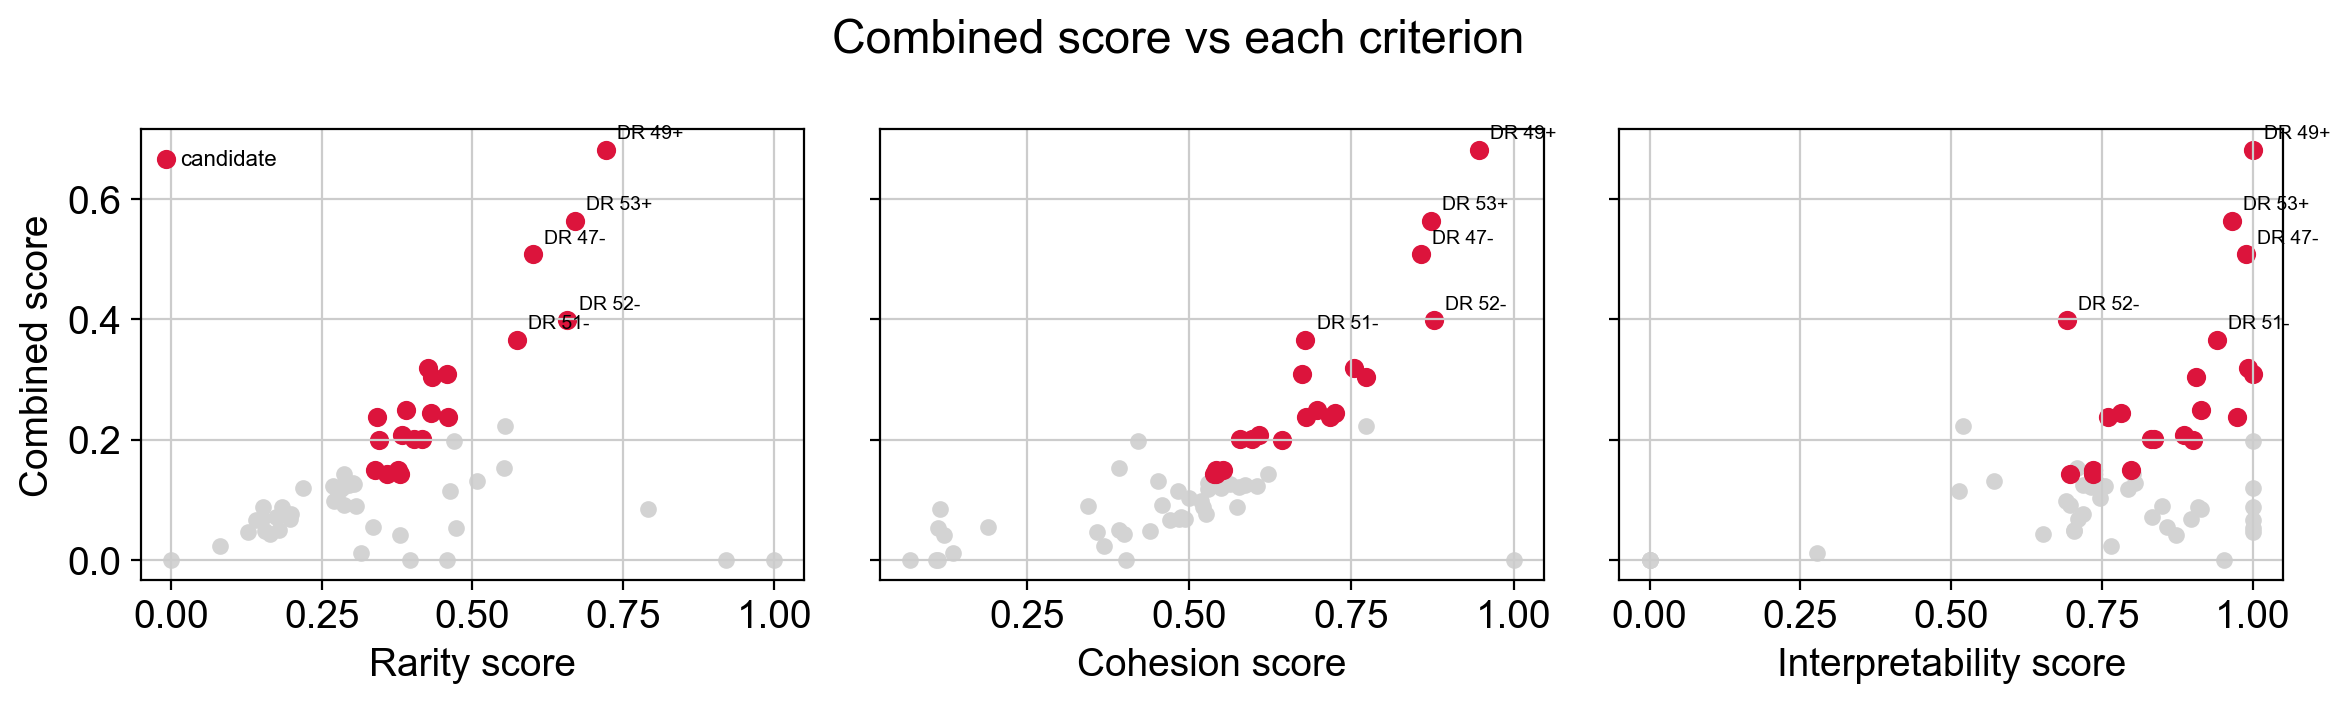

In [16]:
top5 = dim_stats.nlargest(5, "score")
components = [
    ("rarity_score", "Rarity score"),
    ("cohesion_score", "Cohesion score"),
    ("interpretability_score", "Interpretability score"),
]

cand = dim_stats[dim_stats["is_candidate"]]
noncand = dim_stats[~dim_stats["is_candidate"]]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, (col, label) in zip(axes, components):
    ax.scatter(noncand[col], noncand["score"], s=25, c="lightgray")
    ax.scatter(cand[col], cand["score"], s=35, c="crimson", label="candidate")
    for dim, r in top5.iterrows():
        ax.annotate(dim, (r[col], r["score"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
    ax.set_xlabel(label)
axes[0].set_ylabel("Combined score")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Combined score vs each criterion")
plt.tight_layout()
plt.show()

## Which candidates are good rare-cell-type candidates?

Now we bring in the existing annotation (`final_annotation`) — but the question is **not** whether a
dimension's active cells carry one label or several. A rare type whose cells are all labeled `X` is no
more or less interesting than one labeled half `X`, half `Y`; both can be perfectly valid known types.

What signals a **hidden population that needs refinement** is different: the active cells are labeled `X`,
yet they make up only a *small fraction of all `X` cells* (say `< 30%`). That means the dimension has
carved out a distinct minority sub-population *inside* an existing annotation — a cell state the label does
not resolve. So for each candidate we compute its **host-annotation coverage**: of all cells carrying the
candidate's dominant label, what fraction are active on this dimension.

- **High coverage** (≈100%) → the dimension simply re-discovers a known annotated type.
- **Low coverage** (`< 30%`) → a sub-population hidden inside that annotation — a refinement candidate.

In [17]:
# Now we finally subset to the candidates (all three criteria) and characterize them by annotation.
candidates = dim_stats[dim_stats["is_candidate"]].copy()

annotation = embed.obs[CELL_TYPE_COL].astype(str).values
annotation_totals = pd.Series(annotation).value_counts()


def host_annotation_coverage(embed, dim_title_direction, annotation, annotation_totals):
    """Dominant label of the active cells, and the fraction of *all* cells with that label
    that this dimension captures."""
    active = active_mask(embed, dim_title_direction)
    counts = pd.Series(annotation[active]).value_counts()
    host = counts.index[0]
    return host, counts.iloc[0] / annotation_totals[host]


coverage = [host_annotation_coverage(embed, dim_title_direction, annotation, annotation_totals)
            for dim_title_direction in candidates.index]
candidates["host_annotation"] = [host for host, _ in coverage]
candidates["host_coverage"] = [cov for _, cov in coverage]

Sorting the candidates by host-annotation coverage: dimensions on the right re-discover whole annotated
types (e.g. one capturing nearly all Plasma cells, another nearly all pDCs), while those **below the 30%
cutoff** are minority sub-populations hidden inside a label. The low-coverage candidates are the **good
rare-cell-type candidates** — cell states the current annotation does not resolve.

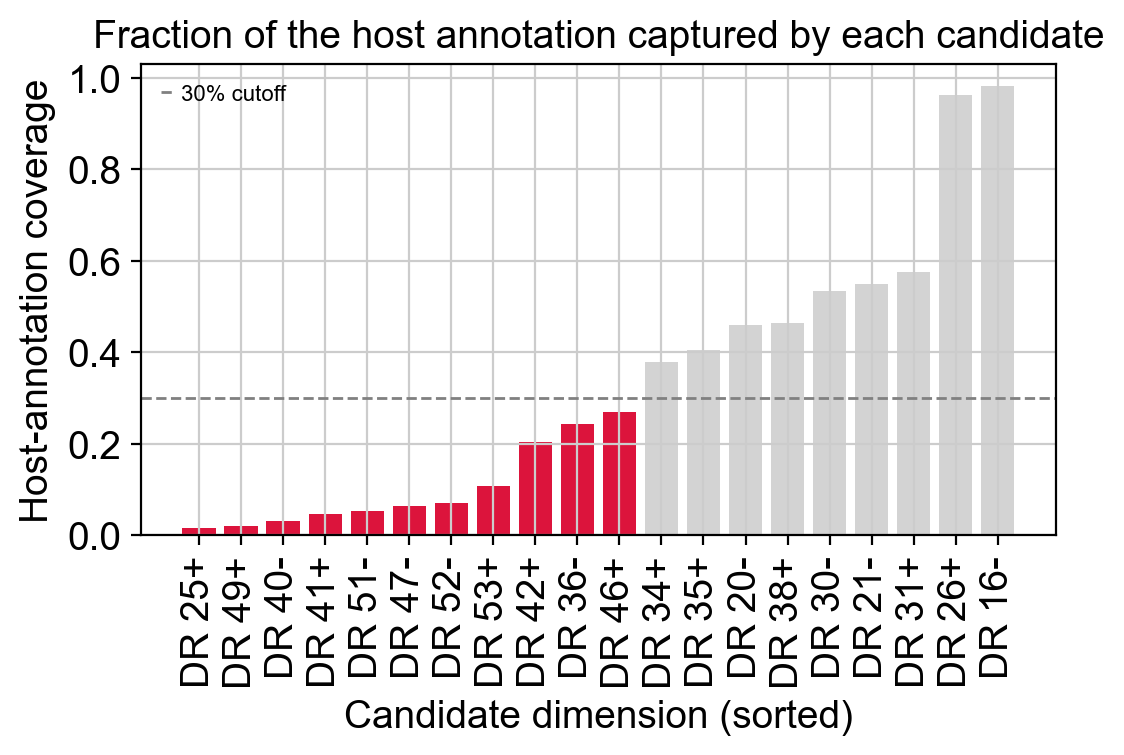

In [18]:
cov_sorted = candidates.sort_values("host_coverage")
colors = ["crimson" if c < HOST_COVERAGE_CUTOFF else "lightgray" for c in cov_sorted["host_coverage"]]

fig, ax = plt.subplots(figsize=(max(5.0, 0.28 * len(cov_sorted)), 4))
ax.bar(cov_sorted.index, cov_sorted["host_coverage"], color=colors)
ax.axhline(HOST_COVERAGE_CUTOFF, ls="--", c="gray", lw=1, label=f"{HOST_COVERAGE_CUTOFF:.0%} cutoff")
ax.set_ylabel("Host-annotation coverage")
ax.set_xlabel("Candidate dimension (sorted)")
ax.set_title("Fraction of the host annotation captured by each candidate")
ax.tick_params(axis="x", rotation=90)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
unannotated_candidates = candidates[candidates["host_coverage"] < HOST_COVERAGE_CUTOFF]
print(f"{len(unannotated_candidates)} unannotated candidates (host coverage < {HOST_COVERAGE_CUTOFF:.0%}).")
unannotated_candidates

11 unannotated candidates (host coverage < 30%).


,n_active,fraction_active,max_ood_score,cohesion,is_candidate,rarity_score,cohesion_score,interpretability_score,score,host_annotation,host_coverage
dim_title_direction,,,,,,,,,,,
DR 49+,11,0.000339,10.000000,0.946676,True,0.720925,0.946676,1.000000,0.682483,HSPCs,0.021142
DR 53+,17,0.000523,7.863610,0.872461,True,0.670261,0.872461,0.965207,0.564431,Plasma cells,0.108527
DR 47-,31,0.000954,9.252443,0.857012,True,0.600341,0.857012,0.988752,0.508713,Monocyte-derived dendritic cells,0.064854
DR 52-,19,0.000585,1.186559,0.877492,True,0.657317,0.877492,0.691430,0.398810,Megakaryocyte progenitors,0.070370
DR 51-,39,0.001201,6.611659,0.679271,True,0.573623,0.679271,0.940103,0.366307,Monocyte-derived dendritic cells,0.054393
DR 42+,106,0.003263,10.000000,0.674241,True,0.457254,0.674241,1.000000,0.308299,Monocyte progenitors,0.203271
DR 41+,130,0.004002,5.237628,0.772638,True,0.433500,0.772638,0.906378,0.303581,NK cells,0.047515
DR 25+,189,0.005818,5.538978,0.696726,True,0.389948,0.696726,0.914477,0.248451,CD4+ T cells,0.016620
DR 46+,133,0.004094,2.203843,0.724096,True,0.430845,0.724096,0.781060,0.243670,Monocyte-derived dendritic cells,0.269874


## Inspect the good candidates

For every good rare-cell-type candidate we look at *where* its active cells sit in the latent UMAP and
*which genes* define it. Each candidate should light up a small, coherent region (cohesion) with a
distinct gene program (interpretability).

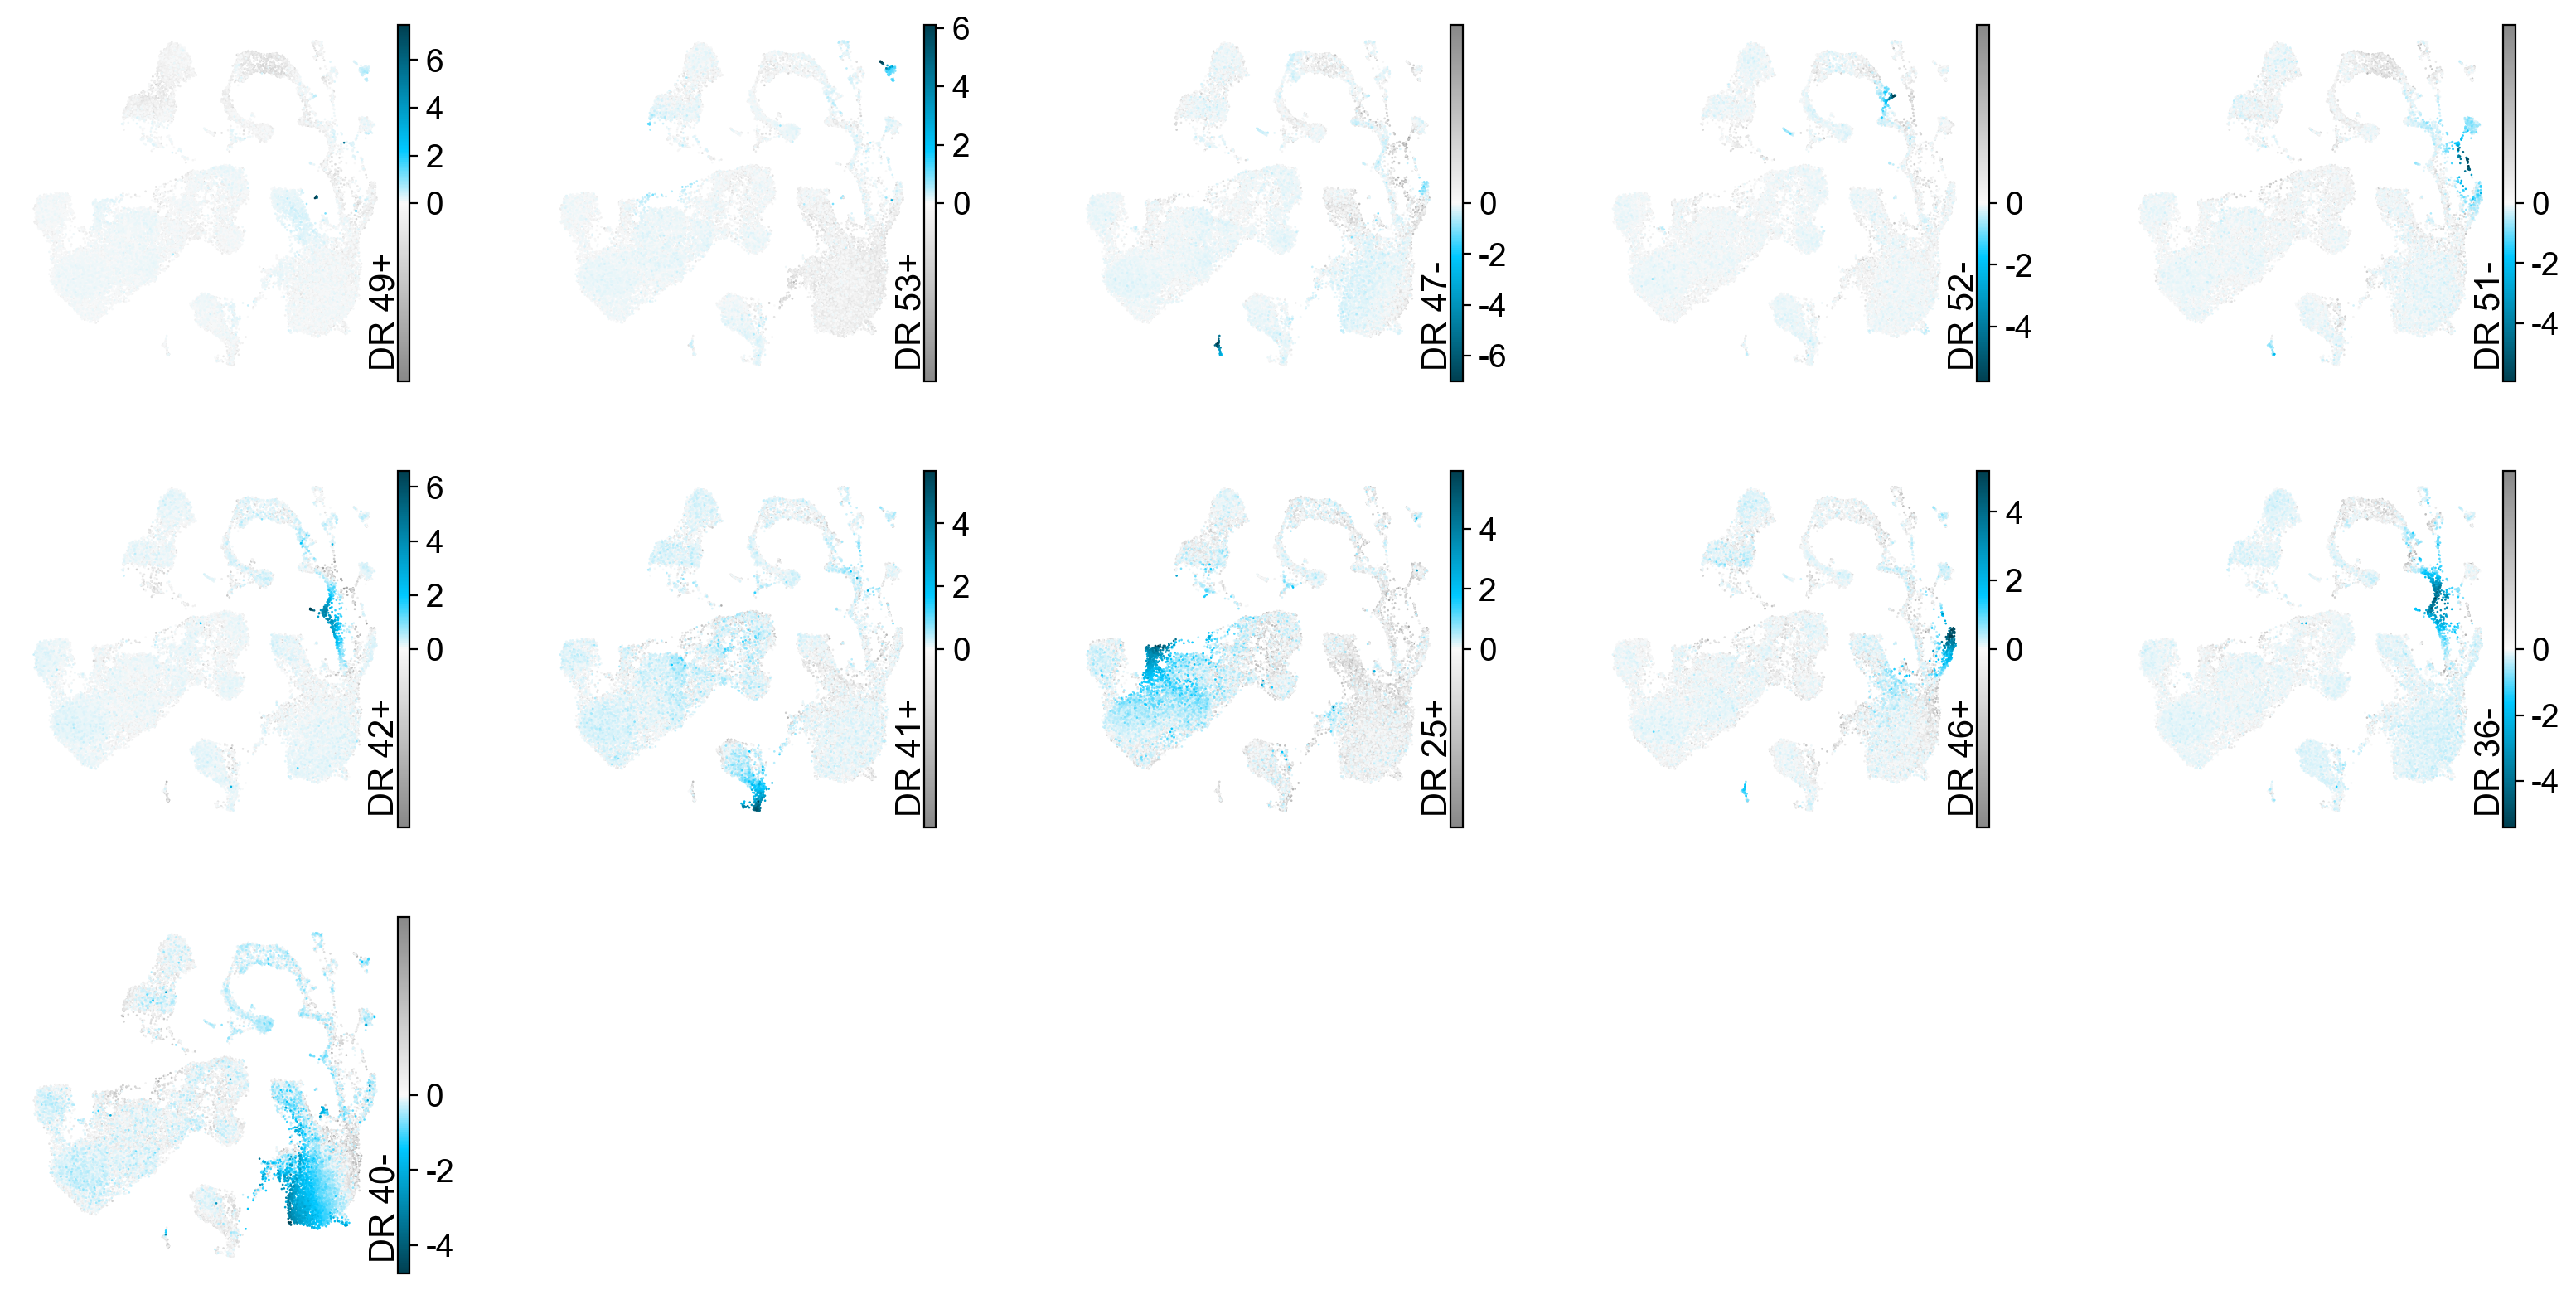

In [20]:
candidate_dims = unannotated_candidates.index.to_list()
drvi.utils.pl.plot_latent_dims_in_umap(embed, dim_subset=candidate_dims, directional=True, ncols=5)

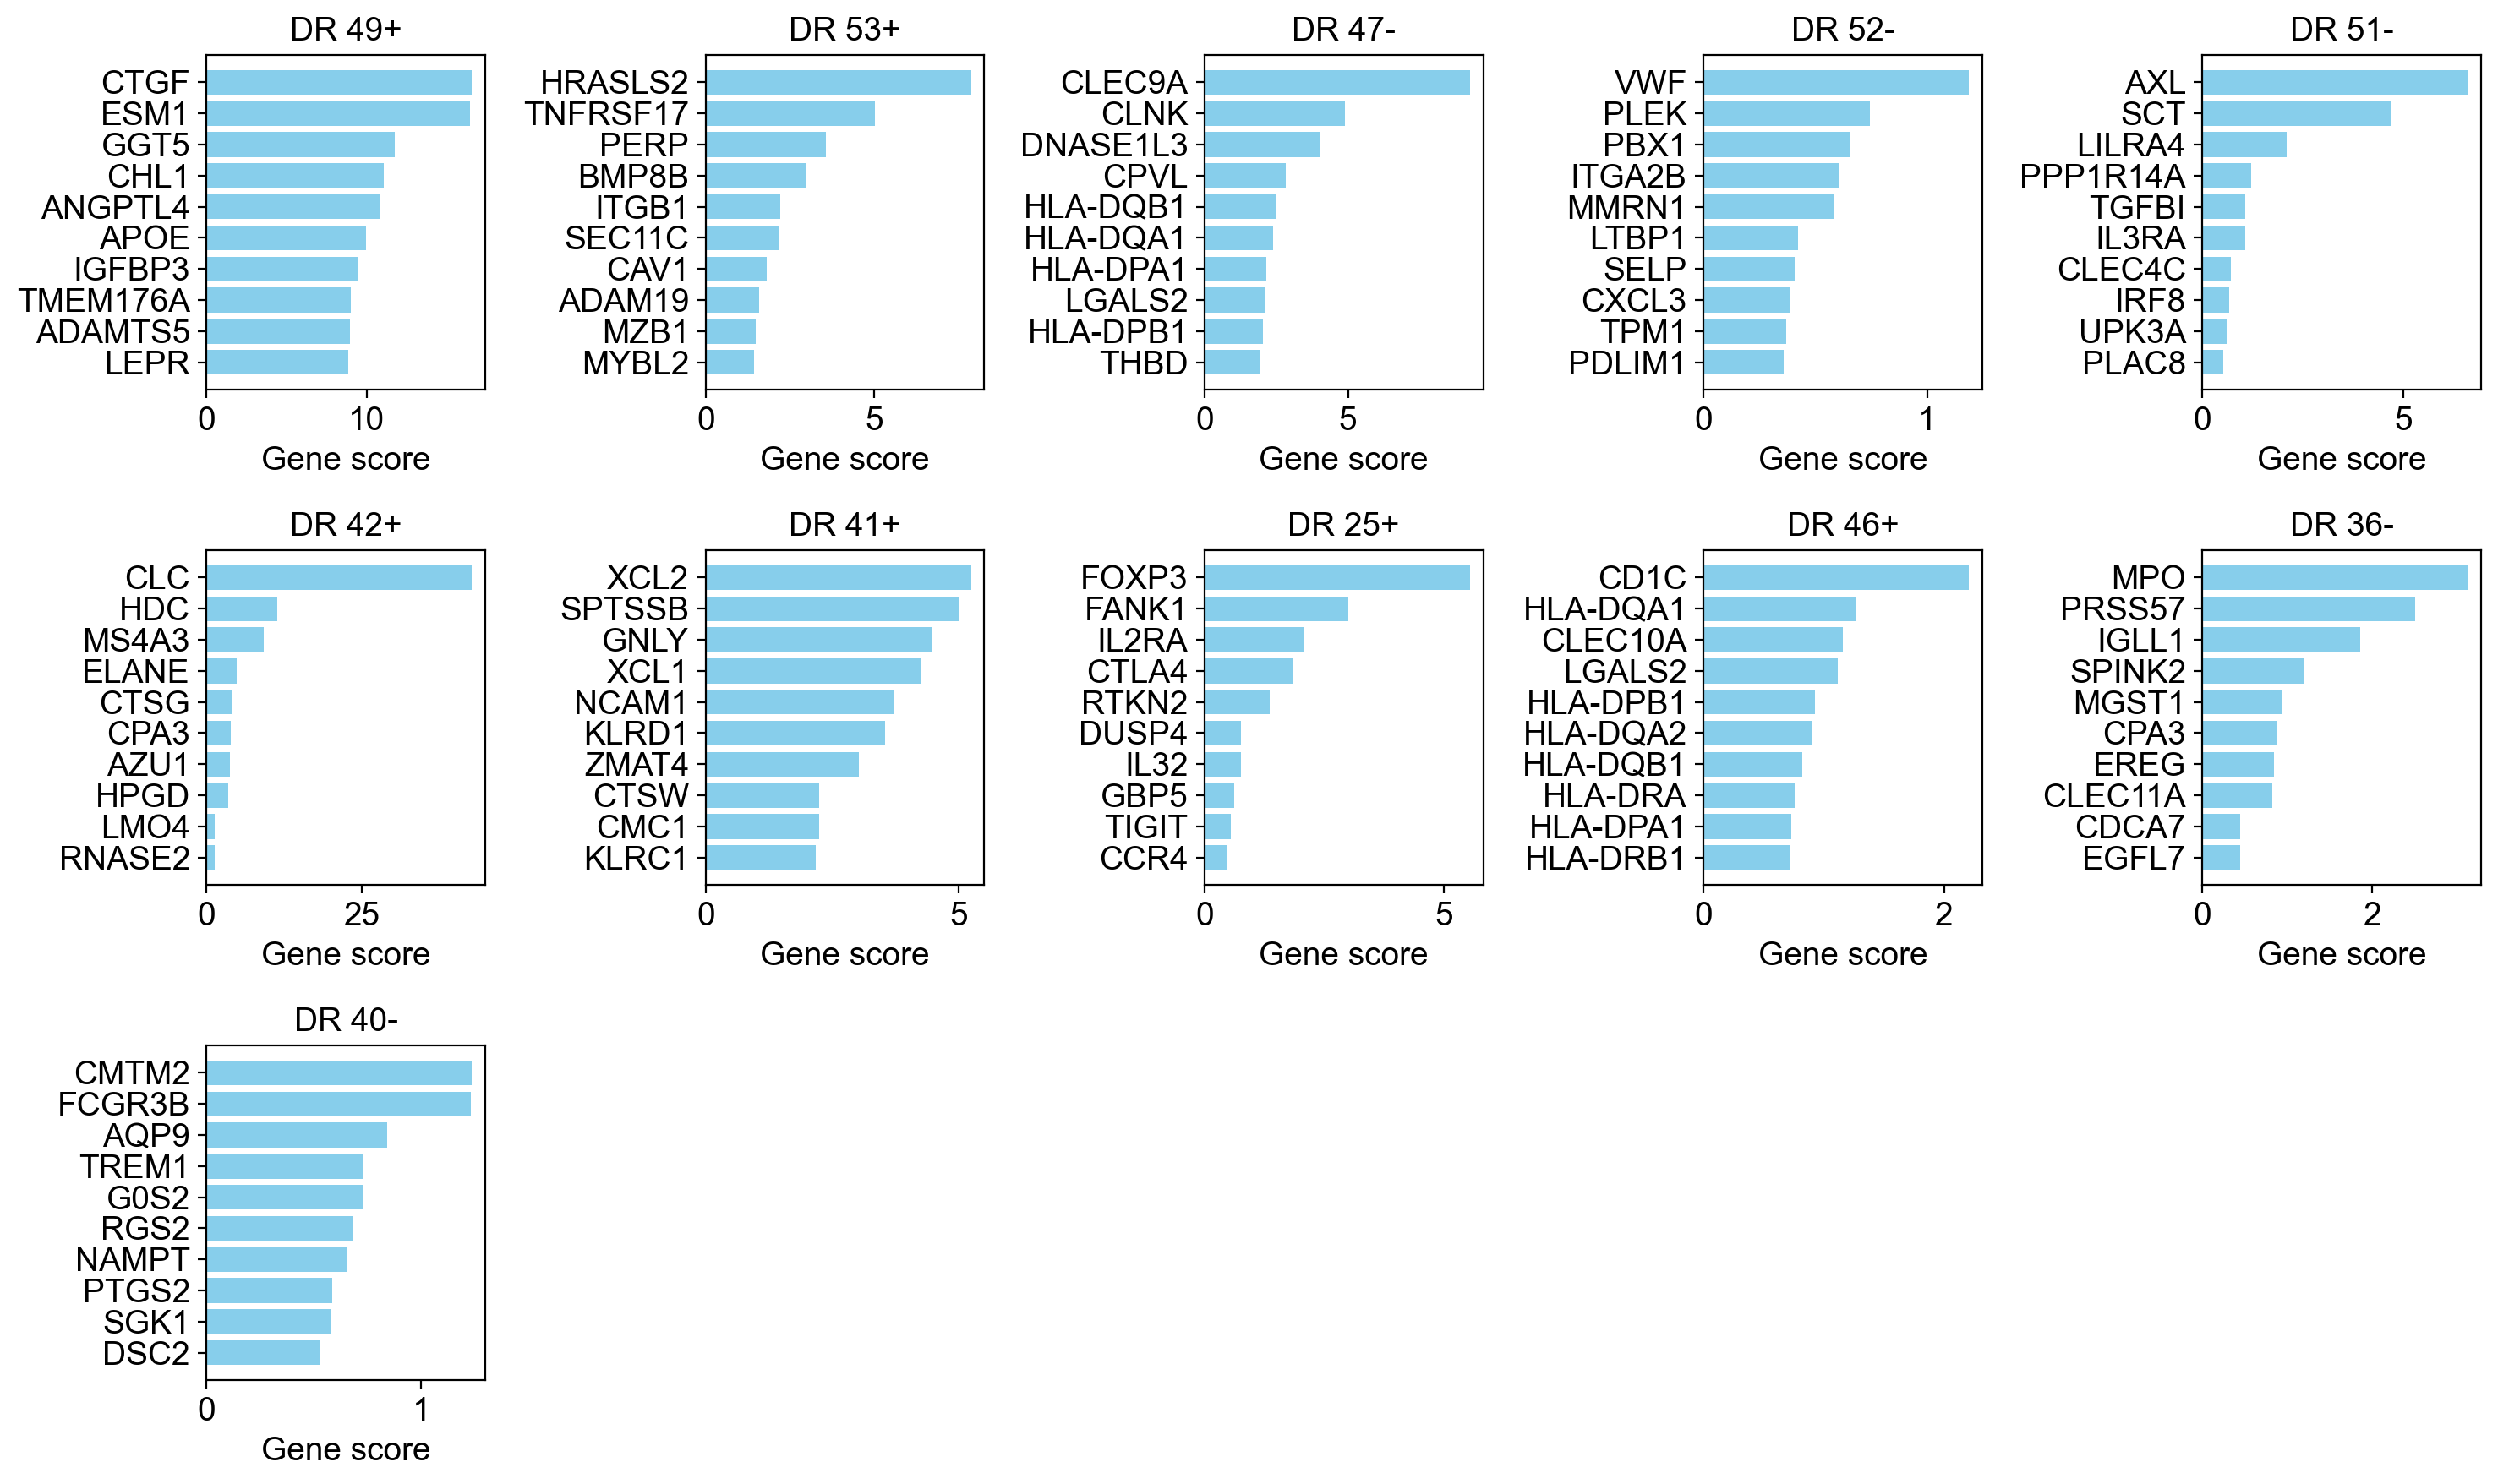

In [21]:
# `interpretability_df` (from get_interpretability_scores) already holds the gene x dimension scores;
# we plot it directly with the utility function.
drvi.utils.pl.plot_interpretability_scores(interpretability_df, dim_subset=candidate_dims)

The candidates above represent rare cell types or substantially finer subclusters than the existing
annotations. These subsets can usually be identified from their top marker genes.

## A closer look: discovering the fibroblasts

Among the candidates, the **rarest** one stands out: a tiny dimension (about a dozen cells) whose cells are
filed under `HSPCs` yet are only ~2% of all HSPCs. Let us follow it end-to-end — identify it, read its gene
program, and prove what it is.

In [22]:
novel_dim = unannotated_candidates["fraction_active"].idxmin()   # signed title of the rarest unannotated candidate
novel = unannotated_candidates.loc[novel_dim]
print(f"Rarest candidate: {novel_dim} "
      f"({int(novel['n_active'])} active cells, "
      f"filed under '{novel['host_annotation']}' = {novel['host_coverage']:.0%} of that label)")

Rarest candidate: DR 49+ (11 active cells, filed under 'HSPCs' = 2% of that label)


Where do these cells sit in the latent UMAP, and what gene program defines the dimension?

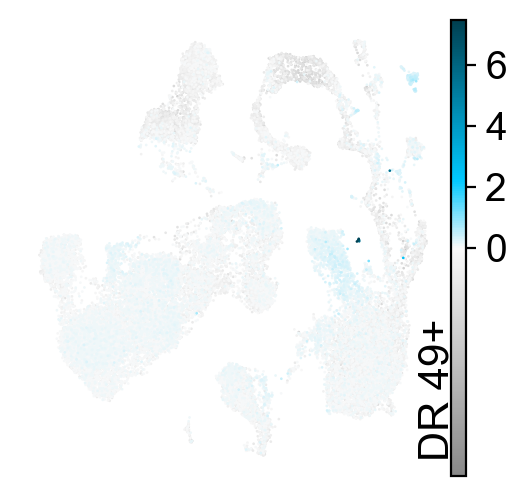

In [23]:
drvi.utils.pl.plot_latent_dims_in_umap(embed, dim_subset=[novel_dim], directional=True)

In [24]:
# Top genes of the dimension from the OOD interpretability scores computed earlier.
top_genes = interpretability_df[novel_dim].sort_values(ascending=False).head(15)
top_genes

index
CTGF        16.571640
ESM1        16.453259
GGT5        11.744933
CHL1        11.075085
ANGPTL4     10.839233
APOE         9.956375
IGFBP3       9.464321
TMEM176A     8.986181
ADAMTS5      8.935850
LEPR         8.833106
PCOLCE       8.585531
TNFAIP6      8.509926
APOD         8.253377
CYP1B1       8.215638
SOCS3        7.993906
Name: DR 49+, dtype: float32

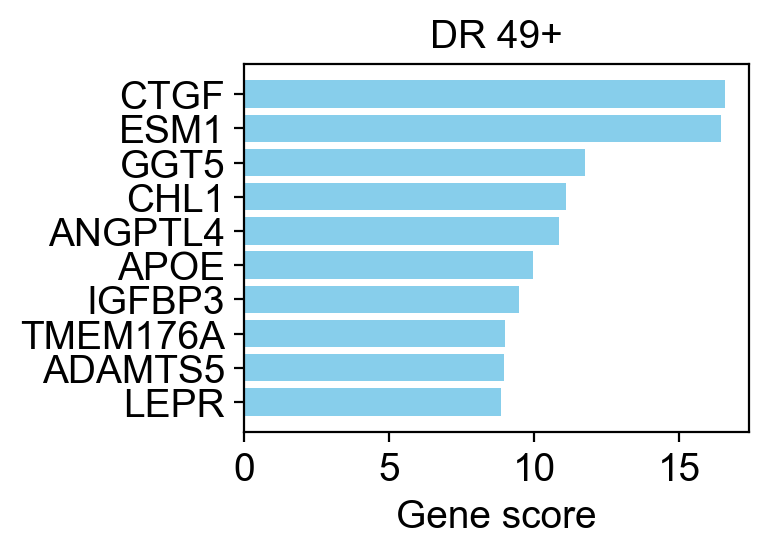

In [25]:
drvi.utils.pl.plot_interpretability_scores(interpretability_df, dim_subset=[novel_dim])

The program is dominated by extracellular-matrix / stromal genes — **CTGF (CCN2), PCOLCE, ADAMTS5,
IGFBP3, APOD, ANGPTL4** — none of which belong to immune cells. The hypothesis is clear: these few cells
are **fibroblasts**, a stromal contaminant that the annotation merged into HSPCs.

Crucially, the canonical fibroblast marker `COL1A1` is **not** in the 2000 HVGs, so the model never saw
it. That makes it a perfect *independent* test of the hypothesis.

### Validate with the held-out marker `COL1A1`

We load the full gene set, label the active cells of the novel dimension as `Fibroblast (DRVI)`, and show
that `COL1A1` lights up specifically in this group — and not in the HSPCs they were mislabeled as.

In [26]:
# The full matrix (~2 GB) is only needed here.
full = sc.read_h5ad(full_anndata_path)
full = full[embed.obs_names].copy()

assert "COL1A1" not in adata.var_names, "COL1A1 should be held out from the HVGs the model trained on"
assert "COL1A1" in full.var_names, "COL1A1 must be present in the full gene set"

In [27]:
# Ensure a log-normalized layer for the dotplot.
full.layers["log1p"] = full.layers["counts"].copy()
full.X = full.layers["log1p"]
sc.pp.normalize_total(full)
sc.pp.log1p(full)
full.layers["log1p"] = full.X.copy()

In [28]:
# Label the active cells of the novel dimension; everyone else keeps their original annotation.
active_novel = active_mask(embed, novel_dim)
full.obs["new_cell_type"] = np.where(
    active_novel, "Fibroblast (DRVI)", full.obs[CELL_TYPE_COL].astype(str)
)
print(full.obs["new_cell_type"].value_counts().loc[["Fibroblast (DRVI)"]])

new_cell_type
Fibroblast (DRVI)    11
Name: count, dtype: int64


Marker dotplot. `COL1A1` is the held-out proof; the stromal HVG genes are the program DRVI used; `CD34`
is shown as a contrast marker for the HSPCs these cells were labeled as.

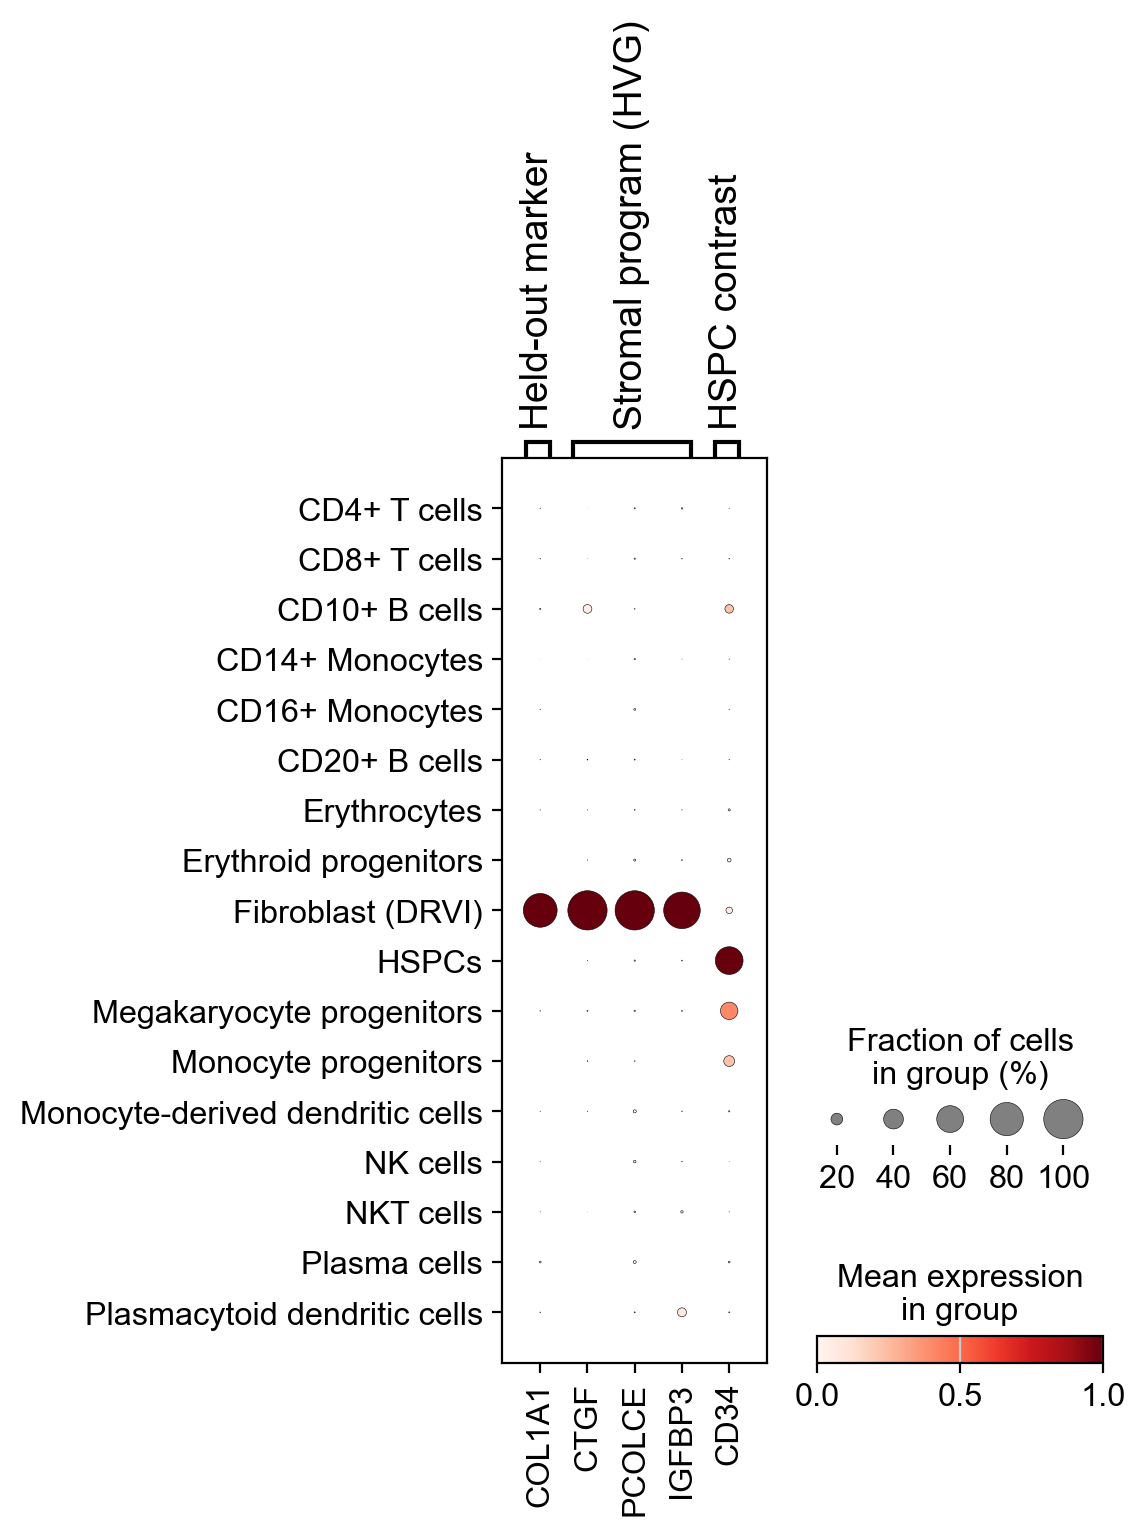

In [29]:
marker_genes = {
    "Held-out marker": ["COL1A1"],
    "Stromal program (HVG)": ["CTGF", "PCOLCE", "IGFBP3"],
    "HSPC contrast": ["CD34"],
}
sc.pl.dotplot(
    full,
    marker_genes,
    groupby="new_cell_type",
    standard_scale="var",
    layer="log1p",
    show=True,
)

### Quantitative proof

In [30]:
col1a1 = np.asarray(
    full[:, "COL1A1"].layers["counts"].todense()
    if hasattr(full[:, "COL1A1"].layers["counts"], "todense")
    else full[:, "COL1A1"].layers["counts"]
).ravel()

frac_in_dim = (col1a1[active_novel] > 0).mean()
n_total_pos = int((col1a1 > 0).sum())
print(f"COL1A1+ among the {int(active_novel.sum())} cells of {novel_dim}: {frac_in_dim:.0%}")
print(f"COL1A1+ cells in the whole dataset: {n_total_pos} / {full.n_obs}")

COL1A1+ among the 11 cells of DR 49+: 82%
COL1A1+ cells in the whole dataset: 67 / 32484


A large majority of the dimension's cells express `COL1A1`, while only ~70 cells express it across the
entire dataset (of >32,000) — overwhelming, *independent* confirmation that DRVI isolated the fibroblasts.

### Where are the fibroblasts in the UMAP?

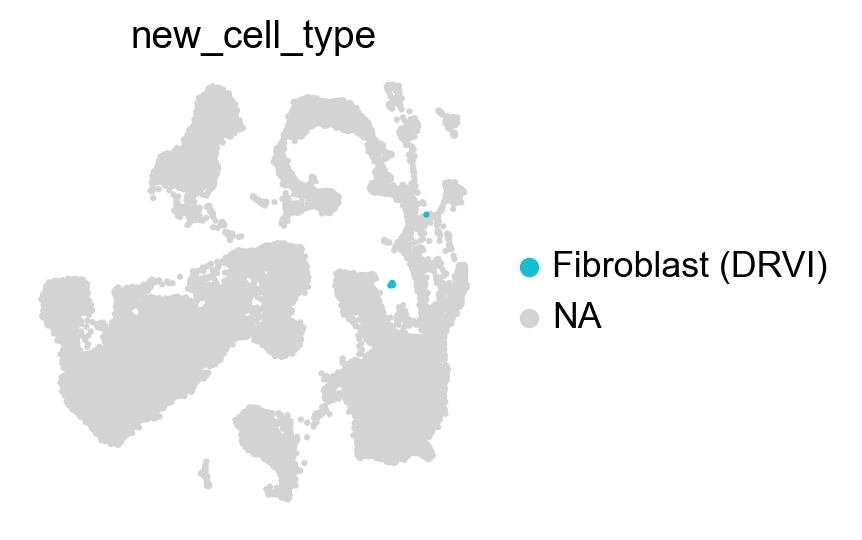

In [31]:
embed.obs["new_cell_type"] = full.obs["new_cell_type"].values
sc.pl.umap(embed, color="new_cell_type", groups=["Fibroblast (DRVI)"], size=20, frameon=False)

## Wrap-up

Rare, un-annotated populations surface in DRVI as **dedicated latent dimensions**. The recipe:

1. **Rarity & interpretability** — few active cells (`|latent|` past half the dimension's peak) and a specific gene program (max OOD score `> 1`).
2. **Spatial cohesion** — the active cells form a tight blob on the UMAP (high UMAP cohesion).
3. **Spot the ones needing refinement** — candidates that capture only a small fraction (`< 30%`) of their
   host annotation are hidden sub-populations the labels do not resolve.
4. **Propose an identity** — read the dimension's top interpretability genes.
5. **Confirm it [optional]** — with an independent, held-out marker (`COL1A1` for fibroblasts here).

All thresholds (the activity cutoff, the rare-fraction, cohesion, OOD, and host-coverage cutoffs) are
tunable. Here the activity cutoff is **adaptive** — half of each dimension's peak `|latent|`
(`max(|value|) / 2`), which self-calibrates per dimension; a fixed cutoff such as `±2` is a common
alternative. The same recipe works for any rare population in any DRVI model — the immune fibroblasts are
just a clean illustration.